# Assignment 3 – Shared Data Preparation Notebook

This notebook prepares the VizWiz-Captions validation split for the group image captioning assignment.

It creates clean metadata, image-level train/validation/test splits, a training vocabulary, reference captions for BLEU evaluation, and reusable PyTorch dataset utilities.

## 1. Setup

The project uses relative paths so that every group member can run the same notebook locally.

In [1]:
# Import standard libraries for data preparation and basic inspection.
from pathlib import Path
from collections import Counter
import json
import random
import re
import shutil
import unicodedata
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

# Stop pandas from truncating long string cells (e.g. vizwiz_url, full captions).
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 200)

In [2]:
# Define all input and output paths in one place.
DATA_DIR = Path("./data")
OUTPUT_DIR = Path("./output")
ANNOTATION_ZIP = DATA_DIR / "annotations.zip"
VAL_JSON = DATA_DIR / "annotations" / "val.json"
VAL_IMAGE_ZIP = DATA_DIR / "val.zip"
VAL_IMAGE_DIR = DATA_DIR / "val"

# Source URLs from the assignment brief (VizWiz-Captions validation split).
ANNOTATION_ZIP_URL = "https://vizwiz.cs.colorado.edu/VizWiz_final/caption/annotations.zip"
VAL_IMAGE_ZIP_URL = "https://vizwiz.cs.colorado.edu/VizWiz_final/images/val.zip"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Data preparation settings.
SEED = 42
MIN_WORD_FREQ = 3
DROP_REJECTED_CAPTIONS = True
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RUN_DATALOADER_TEST = True  # This cell safely skips the test if images are not available.

print(f"DATA_DIR: {DATA_DIR.resolve()}")
print(f"OUTPUT_DIR: {OUTPUT_DIR.resolve()}")

DATA_DIR: C:\Users\Administrator\Desktop\uts\94691\AT3\DeepLearning_AT3_workload\assignment3_notebook\data
OUTPUT_DIR: C:\Users\Administrator\Desktop\uts\94691\AT3\DeepLearning_AT3_workload\assignment3_notebook\output


In [3]:
# Fix random seeds so that the split and vocabulary are reproducible.
random.seed(SEED)
np.random.seed(SEED)
print(f"Seed fixed at {SEED}")

Seed fixed at 42


## 2. Load VizWiz validation annotations

The assignment specifies the VizWiz validation set with 7,750 images. Therefore, this notebook uses `annotations/val.json` from `annotations.zip`.

In [4]:
# Download VizWiz files from the project site if they are not already present.
# annotations.zip is small (~10 MB) but val.zip is ~2 GB, so we stream both with
# a tqdm progress bar that uses Content-Length when the server provides it.
def download_if_missing(url: str, destination: Path) -> None:
    """Download `url` to `destination` only if the file does not yet exist (with tqdm progress)."""
    if destination.exists() and destination.stat().st_size > 0:
        print(f"Already present: {destination} ({destination.stat().st_size:,} bytes)")
        return
    destination.parent.mkdir(parents=True, exist_ok=True)
    tmp = destination.with_suffix(destination.suffix + ".part")
    print(f"Downloading {url} -> {destination}")
    with urllib.request.urlopen(url) as response:
        total = int(response.headers.get("Content-Length", 0)) or None
        chunk_size = 1024 * 1024  # 1 MiB
        with open(tmp, "wb") as out, tqdm(
            total=total, unit="B", unit_scale=True, unit_divisor=1024,
            desc=destination.name,
        ) as pbar:
            while True:
                chunk = response.read(chunk_size)
                if not chunk:
                    break
                out.write(chunk)
                pbar.update(len(chunk))
    tmp.rename(destination)
    print(f"Downloaded: {destination} ({destination.stat().st_size:,} bytes)")


def extract_zip_with_progress(zip_path: Path, dest_dir: Path) -> None:
    """Extract `zip_path` into `dest_dir` showing a tqdm progress bar over members."""
    dest_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        members = zf.infolist()
        for member in tqdm(members, desc=f"Extracting {zip_path.name}"):
            zf.extract(member, dest_dir)


# Annotations: download + extract if val.json is missing.
if not VAL_JSON.exists():
    download_if_missing(ANNOTATION_ZIP_URL, ANNOTATION_ZIP)
    extract_zip_with_progress(ANNOTATION_ZIP, DATA_DIR)

if not VAL_JSON.exists():
    raise FileNotFoundError(f"Could not find {VAL_JSON} after extraction.")

print(f"Using annotation file: {VAL_JSON}")

# Validation images: download val.zip and extract to DATA_DIR/val if not yet
# present. The dataloaders can read either from the extracted folder or directly
# from the zip, but the extracted folder is much faster.
if not VAL_IMAGE_DIR.exists() or not any(VAL_IMAGE_DIR.iterdir()):
    download_if_missing(VAL_IMAGE_ZIP_URL, VAL_IMAGE_ZIP)
    extract_zip_with_progress(VAL_IMAGE_ZIP, DATA_DIR)

if VAL_IMAGE_DIR.exists():
    n_images = sum(1 for _ in VAL_IMAGE_DIR.iterdir())
    print(f"Validation images ready at {VAL_IMAGE_DIR} ({n_images:,} files)")
else:
    print(f"Warning: {VAL_IMAGE_DIR} not found after extraction.")

Using annotation file: data\annotations\val.json


In [5]:
# Read the VizWiz validation annotation JSON.
with open(VAL_JSON, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

images_df = pd.DataFrame(raw_data["images"])
annotations_df = pd.DataFrame(raw_data["annotations"])

print(f"Number of images: {len(images_df):,}")
print(f"Number of caption rows: {len(annotations_df):,}")
display(images_df.head())
display(annotations_df.head())

Number of images: 7,750
Number of caption rows: 38,750


,file_name,vizwiz_url,id,text_detected
0,VizWiz_val_00000000.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23431,True
1,VizWiz_val_00000001.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23432,True
2,VizWiz_val_00000002.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23433,True
3,VizWiz_val_00000003.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23434,True
4,VizWiz_val_00000004.jpg,https://ivc.ischool.utexas.edu/VizWiz_visualiz...,23435,True


,caption,image_id,is_precanned,is_rejected,id,text_detected
0,A computer screen shows a repair prompt on the...,23431,False,False,117155,True
1,a computer screen with a repair automatically ...,23431,False,False,117156,True
2,partial computer screen showing the need of re...,23431,False,False,117157,True
3,Part of a computer monitor showing a computer ...,23431,False,False,117158,True
4,The top of a laptop with a blue background and...,23431,False,False,117159,True


## 3. Build a clean caption table

Each image has up to five captions. Rejected captions are removed because they are not reliable target descriptions.

In [6]:
# Rename identifier columns before merging so their roles are explicit.
images_df = images_df.rename(columns={"id": "image_id"})
annotations_df = annotations_df.rename(columns={"id": "caption_id"})

caption_df = annotations_df.merge(
    images_df[["image_id", "file_name", "vizwiz_url"]],
    on="image_id",
    how="left"
)

print(f"Rows before filtering: {len(caption_df):,}")

# Remove rejected captions if requested.
if DROP_REJECTED_CAPTIONS and "is_rejected" in caption_df.columns:
    caption_df = caption_df[caption_df["is_rejected"] == False].copy()

print(f"Rows after filtering: {len(caption_df):,}")
print(f"Unique images after filtering: {caption_df['image_id'].nunique():,}")

Rows before filtering: 38,750
Rows after filtering: 37,786
Unique images after filtering: 7,750


In [7]:
# Define a small, transparent text cleaning function.
def clean_caption(text: str) -> str:
    """Return a lowercase, normalized caption.

    Steps:
      1. NFKC-normalize and lowercase.
      2. Replace `& $ % £` with the spelled-out word so semantics survive.
      3. Collapse digit runs (incl. ``9:32``, ``7.51``, ``2,940``, ``07/25/2011``)
         into a single ``<num>`` token — the model cannot OCR specific digits.
      4. Drop everything that is not ``a-z``, ``<``, ``>``, or space (this also
         strips apostrophes, so contractions like ``don't`` split into
         ``don`` + ``t``).
      5. Collapse whitespace.
    """
    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = (
        text.replace("&", " and ")
        .replace("$", " dollar ")
        .replace("%", " percent ")
        .replace("£", " pound ")
    )
    text = re.sub(r"\d+(?:[.,:/]\d+)*", " <num> ", text)
    text = re.sub(r"[^a-z<> ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Add cleaned caption text and token length.
caption_df["caption_clean"] = caption_df["caption"].apply(clean_caption)
caption_df["tokens"] = caption_df["caption_clean"].str.split()
caption_df["caption_word_count"] = caption_df["tokens"].apply(len)

# Remove empty captions after cleaning.
caption_df = caption_df[caption_df["caption_word_count"] > 0].copy()

display(caption_df[["image_id", "file_name", "caption", "caption_clean", "caption_word_count"]].head(10))

,image_id,file_name,caption,caption_clean,caption_length
0,23431,VizWiz_val_00000000.jpg,A computer screen shows a repair prompt on the...,a computer screen shows a repair prompt on the...,10
1,23431,VizWiz_val_00000000.jpg,a computer screen with a repair automatically ...,a computer screen with a repair automatically ...,9
2,23431,VizWiz_val_00000000.jpg,partial computer screen showing the need of re...,partial computer screen showing the need of re...,8
3,23431,VizWiz_val_00000000.jpg,Part of a computer monitor showing a computer ...,part of a computer monitor showing a computer ...,10
4,23431,VizWiz_val_00000000.jpg,The top of a laptop with a blue background and...,the top of a laptop with a blue background and...,13
5,23432,VizWiz_val_00000001.jpg,A person is holding a bottle that has medicine...,a person is holding a bottle that has medicine...,13
6,23432,VizWiz_val_00000001.jpg,A bottle of medication has a white twist top.,a bottle of medication has a white twist top,9
7,23432,VizWiz_val_00000001.jpg,night time medication bottle being held by som...,night time medication bottle being held by som...,8
8,23432,VizWiz_val_00000001.jpg,a person holding a small black bottle of NIGHT...,a person holding a small black bottle of night...,10
9,23432,VizWiz_val_00000001.jpg,A bottle of what appears to be cough syrup hel...,a bottle of what appears to be cough syrup hel...,12


In [ ]:
# Inspect which characters were dropped by clean_caption so we know what we lost.
# Anything not in [a-z0-9' ] is removed by the regex; we count how often each such
# character appeared in the raw captions (after lowercasing) to make sure we are not
# silently discarding meaningful content (e.g. accented letters in foreign words).
dropped_char_counter = Counter()
for raw in caption_df["caption"].astype(str):
    for ch in raw.lower():
        if not re.match(r"[a-z0-9' ]", ch):
            dropped_char_counter[ch] += 1

dropped_chars_df = (
    pd.DataFrame(dropped_char_counter.most_common(), columns=["character", "count"])
    .assign(unicode_name=lambda d: d["character"].map(lambda c: f"U+{ord(c):04X}"))
)
print(f"Distinct characters removed by clean_caption: {len(dropped_chars_df)}")
print(f"Total character occurrences removed: {int(dropped_chars_df['count'].sum()):,}")
display(dropped_chars_df.head(30))

In [ ]:
# EDA: show up to 20 in-context examples for every dropped character so we can
# judge whether stripping it is safe. For characters with more than 20 hits we
# split the examples into three buckets based on the surrounding whitespace:
#   - preceded by ws  (something like " ,word" or " . end")
#   - followed by ws  (something like "word, " or "end. ")
#   - neither         (embedded inside a token, e.g. "don't", "5'2", "r&b")
# The "preceded" and "followed" buckets overlap when whitespace is on both
# sides (the common ", " case); that's intentional — we just want to see real
# usage, not enforce mutually exclusive sets. Newlines in the source caption
# are rendered as the literal string "\\n" so the marker stays on one line.
SAMPLES_PER_BUCKET = 20
WINDOW = 30  # characters of context on either side of the target character

raw_lc_captions = caption_df["caption"].astype(str).str.lower().tolist()


def _format_context(text: str, idx: int) -> str:
    """Return a one-line context snippet with the target char wrapped in « »."""
    start = max(0, idx - WINDOW)
    end = min(len(text), idx + 1 + WINDOW)
    snippet = text[start:idx] + "«" + text[idx] + "»" + text[idx + 1:end]
    snippet = snippet.replace("\n", "\\n").replace("\r", "\\r").replace("\t", "\\t")
    prefix = "…" if start > 0 else ""
    suffix = "…" if end < len(text) else ""
    return f"{prefix}{snippet}{suffix}"


for ch, total in dropped_char_counter.most_common():
    header = f"=== {ch!r}  (U+{ord(ch):04X})  total={total:,} ==="
    print("\n" + header)

    if total <= SAMPLES_PER_BUCKET:
        shown = 0
        for text in raw_lc_captions:
            if shown >= SAMPLES_PER_BUCKET:
                break
            for i, c in enumerate(text):
                if c == ch:
                    print("  ", _format_context(text, i))
                    shown += 1
                    if shown >= SAMPLES_PER_BUCKET:
                        break
        continue

    buckets = {"preceded by ws": [], "followed by ws": [], "neither": []}
    for text in raw_lc_captions:
        if all(len(v) >= SAMPLES_PER_BUCKET for v in buckets.values()):
            break
        for i, c in enumerate(text):
            if c != ch:
                continue
            ws_before = i == 0 or text[i - 1].isspace()
            ws_after = i == len(text) - 1 or text[i + 1].isspace()
            ctx = _format_context(text, i)
            if ws_before and len(buckets["preceded by ws"]) < SAMPLES_PER_BUCKET:
                buckets["preceded by ws"].append(ctx)
            if ws_after and len(buckets["followed by ws"]) < SAMPLES_PER_BUCKET:
                buckets["followed by ws"].append(ctx)
            if (not ws_before) and (not ws_after) and len(buckets["neither"]) < SAMPLES_PER_BUCKET:
                buckets["neither"].append(ctx)

    for name, items in buckets.items():
        print(f"  -- {name} ({len(items)}):")
        for ctx in items:
            print("     ", ctx)

In [8]:
# Count how many valid reference captions remain per image after filtering.
valid_caption_distribution = (
    caption_df.groupby("image_id").size()
    .value_counts()
    .sort_index()
    .rename_axis("valid_captions_per_image")
    .reset_index(name="num_images")
)

valid_caption_distribution.to_csv(OUTPUT_DIR / "valid_caption_distribution.csv", index=False)
display(valid_caption_distribution)

,valid_captions_per_image,num_images
0,2,6
1,3,81
2,4,784
3,5,6879


## 4. Basic data inspection

These outputs are designed to be copied into the report or exported into LaTeX tables.

In [9]:
# Create a compact dataset summary table for the report.
dataset_summary = pd.DataFrame([
    {"item": "official_split_used", "value": "VizWiz validation"},
    {"item": "num_images", "value": int(images_df["image_id"].nunique())},
    {"item": "raw_caption_rows", "value": int(len(annotations_df))},
    {"item": "caption_rows_after_filtering", "value": int(len(caption_df))},
    {"item": "unique_images_after_filtering", "value": int(caption_df["image_id"].nunique())},
    {"item": "drop_rejected_captions", "value": bool(DROP_REJECTED_CAPTIONS)},
])

dataset_summary.to_csv(OUTPUT_DIR / "dataset_summary.csv", index=False)
display(dataset_summary)

# Show a few image-level examples with their valid captions.
sample_examples = (
    caption_df.groupby(["image_id", "file_name"])["caption_clean"]
    .apply(list)
    .reset_index(name="valid_captions")
    .head(5)
)
display(sample_examples)

,item,value
0,official_split_used,VizWiz validation
1,num_images,7750
2,raw_caption_rows,38750
3,caption_rows_after_filtering,37786
4,unique_images_after_filtering,7750
5,drop_rejected_captions,True


,image_id,file_name,valid_captions
0,23431,VizWiz_val_00000000.jpg,[a computer screen shows a repair prompt on th...
1,23432,VizWiz_val_00000001.jpg,[a person is holding a bottle that has medicin...
2,23433,VizWiz_val_00000002.jpg,[a white paper showing an image of black and b...
3,23434,VizWiz_val_00000003.jpg,[a white box is to the left of a blue box on a...
4,23435,VizWiz_val_00000004.jpg,[close up of a computer monitor that is powere...


In [10]:
# Summarise caption word counts (tokens = whitespace-split words after cleaning)
# and save the raw frequency table.
caption_word_count_summary = caption_df["caption_word_count"].describe().to_frame("caption_word_count")
caption_word_count_frequency = (
    caption_df["caption_word_count"]
    .value_counts()
    .sort_index()
    .rename_axis("caption_word_count")
    .reset_index(name="frequency")
)

caption_word_count_summary.to_csv(OUTPUT_DIR / "caption_word_count_summary.csv")
caption_word_count_frequency.to_csv(OUTPUT_DIR / "caption_word_count_frequency.csv", index=False)

display(caption_word_count_summary)
display(caption_word_count_frequency.head(20))

# Inspect the longest captions (top-10 outliers) so we can decide on a max length cap.
longest_captions = (
    caption_df.nlargest(10, "caption_word_count")[
        ["image_id", "caption_word_count", "caption_clean"]
    ].reset_index(drop=True)
)
print("Top-10 longest captions (word-count outliers):")
display(longest_captions)

,caption_length
count,37786.000000
mean,11.704944
std,4.225212
min,6.000000
25%,9.000000
50%,10.000000
75%,13.000000
max,155.000000


,caption_length,frequency
0,6,4
1,7,98
2,8,3784
3,9,10020
4,10,5359
5,11,4463
6,12,3392
7,13,2569
8,14,1887
9,15,1396


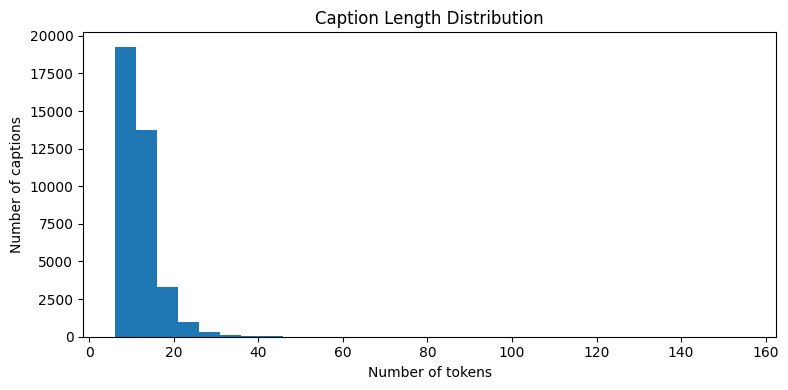

In [11]:
# Plot the caption word-count distribution directly in the notebook.
plt.figure(figsize=(8, 4))
plt.hist(caption_df["caption_word_count"], bins=30)
plt.title("Caption Word-Count Distribution")
plt.xlabel("Words per caption")
plt.ylabel("Number of captions")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "caption_word_count_distribution.png", dpi=150)
plt.show()

## 5. Image-level train / validation / test split

The split is performed at image level to avoid leakage. All valid captions for the same image stay in the same split.

In [12]:
# Create reproducible image-level splits.
unique_image_ids = np.array(sorted(caption_df["image_id"].unique()))
rng = np.random.default_rng(SEED)
rng.shuffle(unique_image_ids)

n_total = len(unique_image_ids)
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)

train_ids = set(unique_image_ids[:n_train])
val_ids = set(unique_image_ids[n_train:n_train + n_val])
test_ids = set(unique_image_ids[n_train + n_val:])

# Assign split labels.
def assign_split(image_id: int) -> str:
    """Return the internal split label for a VizWiz image id."""
    if image_id in train_ids:
        return "train"
    if image_id in val_ids:
        return "val"
    return "test"

caption_df["split"] = caption_df["image_id"].apply(assign_split)

image_split_df = caption_df[["image_id", "file_name", "split"]].drop_duplicates().reset_index(drop=True)
image_split_counts = image_split_df["split"].value_counts().rename_axis("split").reset_index(name="num_images")
caption_split_counts = caption_df["split"].value_counts().rename_axis("split").reset_index(name="num_caption_rows")

split_summary = image_split_counts.merge(caption_split_counts, on="split", how="outer")
split_summary.to_csv(OUTPUT_DIR / "split_summary.csv", index=False)

display(split_summary)

,split,num_images,num_caption_rows
0,test,1163,5695
1,train,5425,26421
2,val,1162,5670


In [13]:
# Verify that no image appears in more than one split.
leakage_check = image_split_df.groupby("image_id")["split"].nunique().max()
assert leakage_check == 1, "Data leakage detected: at least one image appears in multiple splits."
print("Leakage check passed: each image appears in exactly one internal split.")

Leakage check passed: each image appears in exactly one internal split.


## 6. Build vocabulary from training captions only

The vocabulary is built only from the internal training split to avoid using validation/test captions during preprocessing.

In [14]:
# Count words from internal training captions only.
word_counter = Counter()
for tokens in caption_df.loc[caption_df["split"] == "train", "tokens"]:
    word_counter.update(tokens)

special_tokens = ["<pad>", "<start>", "<end>", "<unk>", "<num>"]
# Exclude special tokens from the frequency-derived vocab so they don't get
# duplicate ids — `<num>` is emitted by clean_caption as a real token and will
# show up in word_counter, but it must keep its fixed position in special_tokens.
vocab_words = [
    word for word, count in word_counter.items()
    if count >= MIN_WORD_FREQ and word not in special_tokens
]
vocab_words = sorted(vocab_words)

# Report how many distinct words (and total occurrences) were rejected for being
# below MIN_WORD_FREQ. These will be mapped to <unk> at training time.
rejected_words = [(w, c) for w, c in word_counter.items() if c < MIN_WORD_FREQ]
rejected_unique = len(rejected_words)
rejected_total_occurrences = sum(c for _, c in rejected_words)
total_unique = len(word_counter)
total_occurrences = sum(word_counter.values())
print(
    f"Vocabulary cutoff (MIN_WORD_FREQ={MIN_WORD_FREQ}): "
    f"rejected {rejected_unique:,} / {total_unique:,} unique words "
    f"({rejected_unique / max(total_unique, 1):.1%}), "
    f"covering {rejected_total_occurrences:,} / {total_occurrences:,} token occurrences "
    f"({rejected_total_occurrences / max(total_occurrences, 1):.1%} → <unk>)."
)

# Eyeball the rejected words before they vanish into <unk>. Sorted by count
# (descending) then alphabetically so near-miss words show up first — those are
# the ones most worth re-checking (typos, spelling variants, etc.). Format is
# `word:count`.
rejected_words_sorted = sorted(rejected_words, key=lambda wc: (-wc[1], wc[0]))
rejected_wall = " ".join(f"{w}:{c}" for w, c in rejected_words_sorted)
print(f"\n--- Rejected words (count < {MIN_WORD_FREQ}) ---")
print(rejected_wall)
print(f"--- end of rejected words ({rejected_unique:,} entries) ---\n")

idx2word = special_tokens + vocab_words
word2idx = {word: idx for idx, word in enumerate(idx2word)}

vocab = {
    "word2idx": word2idx,
    "idx2word": idx2word,
    "min_word_freq": MIN_WORD_FREQ,
    "special_tokens": special_tokens,
    "pad_idx": word2idx["<pad>"],
    "start_idx": word2idx["<start>"],
    "end_idx": word2idx["<end>"],
    "unk_idx": word2idx["<unk>"],
}

vocab_summary = pd.DataFrame([
    {"item": "vocabulary_size", "value": len(idx2word)},
    {"item": "min_word_frequency", "value": MIN_WORD_FREQ},
    {"item": "max_caption_word_count", "value": int(caption_df["caption_word_count"].max())},
])

vocab_summary.to_csv(OUTPUT_DIR / "vocab_summary.csv", index=False)

display(vocab_summary)
display(pd.DataFrame(word_counter.most_common(20), columns=["word", "count"]))

,item,value
0,vocabulary_size,4708
1,min_word_frequency,3
2,max_caption_length,155


,word,count
0,a,35481
1,of,14876
2,on,10404
3,the,8809
4,with,8548
5,and,7136
6,to,5457
7,is,5434
8,in,3995
9,are,3852


## 7. Save reusable data files

The model notebooks read these files rather than repeating the shared preprocessing logic.

In [15]:
# Build reference captions for BLEU evaluation.
reference_captions = (
    caption_df.groupby("image_id")["caption_clean"]
    .apply(list)
    .to_dict()
)
reference_captions = {str(k): v for k, v in reference_captions.items()}

# Save processed data and metadata.
caption_df.drop(columns=["tokens"]).to_csv(OUTPUT_DIR / "processed_captions.csv", index=False)
image_split_df.to_csv(OUTPUT_DIR / "image_splits.csv", index=False)
with open(OUTPUT_DIR / "reference_captions.json", "w", encoding="utf-8") as f:
    json.dump(reference_captions, f, indent=2)
with open(OUTPUT_DIR / "vocab.json", "w", encoding="utf-8") as f:
    json.dump(vocab, f, indent=2)

print("Saved processed files:")
for path in [
    "processed_captions.csv",
    "image_splits.csv",
    "reference_captions.json",
    "vocab.json",
    "dataset_summary.csv",
    "caption_word_count_summary.csv",
    "caption_word_count_frequency.csv",
    "valid_caption_distribution.csv",
    "split_summary.csv",
    "vocab_summary.csv",
]:
    print("-", OUTPUT_DIR / path)

Saved processed files:
- output\processed_captions.csv
- output\image_splits.csv
- output\reference_captions.json
- output\vocab.json
- output\dataset_summary.csv
- output\caption_length_summary.csv
- output\caption_length_frequency.csv
- output\valid_caption_distribution.csv
- output\split_summary.csv
- output\vocab_summary.csv


## 8. Save shared PyTorch utility module

The generated module keeps the model notebooks shorter and ensures all students use the same dataset logic.

### Shared utility module (single source of truth)

The cell directly below carries the marker line
`# === SHARED UTILITY MODULE ===` on its first line. Running this notebook
defines the functions/classes here, *and* other notebooks in this folder can
extract this exact cell as a Python module by copying the small extractor
snippet shown after it — no string-blob, no separate `.py` file to keep in
sync.

In [16]:
# === SHARED UTILITY MODULE ===
# Reusable PyTorch dataset utilities for the VizWiz captioning assignment.
# Other notebooks in this folder load this cell verbatim via the extractor below.
from pathlib import Path
from io import BytesIO
import json
import zipfile

import pandas as pd
import torch
from torch.utils.data import Dataset
from PIL import Image


def load_vocab(vocab_path):
    """Load vocabulary metadata saved by the shared preprocessing notebook."""
    with open(vocab_path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_references(reference_path):
    """Load image-level reference captions for BLEU evaluation."""
    with open(reference_path, "r", encoding="utf-8") as f:
        return json.load(f)


def encode_caption(caption, word2idx):
    """Convert a cleaned caption string into token ids with start and end tokens."""
    tokens = str(caption).split()
    ids = [word2idx["<start>"]]
    ids.extend(word2idx.get(token, word2idx["<unk>"]) for token in tokens)
    ids.append(word2idx["<end>"])
    return ids


class VizWizImageReader:
    """Load VizWiz images from an extracted folder or directly from val.zip."""

    def __init__(self, image_dir, image_zip_path=None):
        self.image_dir = Path(image_dir) if image_dir is not None else None
        self.image_zip_path = Path(image_zip_path) if image_zip_path is not None else None
        self._zip_file = None
        self._zip_name_map = None

    def _open_zip(self):
        if self._zip_file is None:
            if self.image_zip_path is None or not self.image_zip_path.exists():
                raise FileNotFoundError("Image folder was not found and val.zip is unavailable.")
            self._zip_file = zipfile.ZipFile(self.image_zip_path, "r")
            self._zip_name_map = {Path(name).name: name for name in self._zip_file.namelist() if not name.endswith("/")}
        return self._zip_file

    def read(self, file_name):
        if self.image_dir is not None:
            image_path = self.image_dir / file_name
            if image_path.exists():
                return Image.open(image_path).convert("RGB")
        zf = self._open_zip()
        zip_name = self._zip_name_map.get(file_name)
        if zip_name is None:
            raise FileNotFoundError(f"Could not find {file_name} in {self.image_zip_path}.")
        with zf.open(zip_name) as f:
            return Image.open(BytesIO(f.read())).convert("RGB")


class VizWizCaptionDataset(Dataset):
    """Caption-row dataset used for training with teacher forcing."""

    def __init__(self, captions_csv, split, vocab, reference_captions, image_dir, image_zip_path=None, transform=None, max_samples=None):
        self.df = pd.read_csv(captions_csv)
        self.df = self.df[self.df["split"] == split].reset_index(drop=True)
        if max_samples is not None:
            self.df = self.df.head(max_samples).reset_index(drop=True)
        self.word2idx = vocab["word2idx"]
        self.reference_captions = reference_captions
        self.reader = VizWizImageReader(image_dir, image_zip_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = self.reader.read(row["file_name"])
        if self.transform is not None:
            image = self.transform(image)
        caption_ids = torch.tensor(encode_caption(row["caption_clean"], self.word2idx), dtype=torch.long)
        image_id = int(row["image_id"])
        references = self.reference_captions[str(image_id)]
        return image, caption_ids, image_id, row["file_name"], references


class VizWizImageDataset(Dataset):
    """Image-level dataset used for validation/test caption generation and BLEU scoring."""

    def __init__(self, captions_csv, split, reference_captions, image_dir, image_zip_path=None, transform=None, max_images=None):
        df = pd.read_csv(captions_csv)
        df = df[df["split"] == split][["image_id", "file_name"]].drop_duplicates().reset_index(drop=True)
        if max_images is not None:
            df = df.head(max_images).reset_index(drop=True)
        self.df = df
        self.reference_captions = reference_captions
        self.reader = VizWizImageReader(image_dir, image_zip_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = self.reader.read(row["file_name"])
        if self.transform is not None:
            image = self.transform(image)
        image_id = int(row["image_id"])
        references = self.reference_captions[str(image_id)]
        return image, image_id, row["file_name"], references


def caption_collate_fn(batch):
    """Pad variable-length training captions inside a batch."""
    images, captions, image_ids, file_names, references = zip(*batch)
    images = torch.stack(images, dim=0)
    lengths = torch.tensor([len(caption) for caption in captions], dtype=torch.long)
    padded = torch.nn.utils.rnn.pad_sequence(captions, batch_first=True, padding_value=0)
    return images, padded, lengths, list(image_ids), list(file_names), list(references)


def image_collate_fn(batch):
    """Collate image-level evaluation batches without caption tensors."""
    images, image_ids, file_names, references = zip(*batch)
    images = torch.stack(images, dim=0)
    return images, list(image_ids), list(file_names), list(references)

Saved shared PyTorch utility module to: output\vizwiz_caption_utils.py


### Extractor snippet — copy verbatim into other notebooks

Paste the cell below into any sibling notebook. It locates the shared cell by
its `# === SHARED UTILITY MODULE ===` marker, writes it to
`./output/vizwiz_caption_utils.py`, and imports it. No editing required.

```python
# --- begin shared-utils extractor (copy verbatim) ---
import json, sys
from pathlib import Path
SHARED_NB = Path("./01_shared_data_preparation.ipynb")
MARKER = "# === SHARED UTILITY MODULE ==="
OUT = Path("./output"); OUT.mkdir(parents=True, exist_ok=True)
nb = json.loads(SHARED_NB.read_text(encoding="utf-8"))
sources = ["".join(c["source"]) for c in nb["cells"] if c["cell_type"] == "code"]
matches = [s for s in sources if s.lstrip().startswith(MARKER)]
assert len(matches) == 1, f"Expected exactly one cell starting with {MARKER!r}, found {len(matches)}"
(OUT / "vizwiz_caption_utils.py").write_text(matches[0], encoding="utf-8")
sys.path.insert(0, str(OUT.resolve()))
import vizwiz_caption_utils
from vizwiz_caption_utils import (
    load_vocab, load_references, encode_caption,
    VizWizImageReader, VizWizCaptionDataset, VizWizImageDataset,
    caption_collate_fn, image_collate_fn,
)
# --- end shared-utils extractor ---
```

In [ ]:
# Self-test the extractor against this notebook so we know the marker survives
# every save and that downstream notebooks will get exactly the same module.
SHARED_NB = Path("./01_shared_data_preparation.ipynb")
MARKER = "# === SHARED UTILITY MODULE ==="
utility_path = OUTPUT_DIR / "vizwiz_caption_utils.py"
if SHARED_NB.exists():
    nb = json.loads(SHARED_NB.read_text(encoding="utf-8"))
    sources = ["".join(c["source"]) for c in nb["cells"] if c["cell_type"] == "code"]
    matches = [s for s in sources if s.lstrip().startswith(MARKER)]
    assert len(matches) == 1, f"Expected exactly one cell starting with {MARKER!r}, found {len(matches)}"
    utility_path.write_text(matches[0], encoding="utf-8")
    print(f"Extracted shared utility cell to: {utility_path}")
else:
    print(f"Skipped extractor self-test: {SHARED_NB} not found (run as a notebook, not a .py).")

## 9. Dataloader smoke test

This test proves that image loading, tensor conversion, caption encoding, and padding work together. It is safe to skip automatically if `val.zip` or extracted images are not available yet.

In [17]:
# Run a small dataloader smoke test if image files are available.
if RUN_DATALOADER_TEST and (VAL_IMAGE_DIR.exists() or VAL_IMAGE_ZIP.exists()):
    import sys
    sys.path.append(str(OUTPUT_DIR.resolve()))
    import torchvision.transforms as transforms
    from torch.utils.data import DataLoader
    from vizwiz_caption_utils import VizWizCaptionDataset, caption_collate_fn, load_vocab, load_references

    smoke_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    smoke_vocab = load_vocab(OUTPUT_DIR / "vocab.json")
    smoke_refs = load_references(OUTPUT_DIR / "reference_captions.json")
    smoke_dataset = VizWizCaptionDataset(
        captions_csv=OUTPUT_DIR / "processed_captions.csv",
        split="train",
        vocab=smoke_vocab,
        reference_captions=smoke_refs,
        image_dir=VAL_IMAGE_DIR,
        image_zip_path=VAL_IMAGE_ZIP,
        transform=smoke_transform,
        max_samples=8,
    )
    smoke_loader = DataLoader(smoke_dataset, batch_size=4, shuffle=False, collate_fn=caption_collate_fn, num_workers=0)
    images, captions, lengths, image_ids, file_names, references = next(iter(smoke_loader))
    print("Dataloader smoke test passed.")
    print("images:", tuple(images.shape))
    print("captions:", tuple(captions.shape))
    print("lengths:", lengths.tolist())
    print("image_ids:", image_ids)
    print("first file:", file_names[0])
    print("first references:", references[0])
else:
    print("Dataloader smoke test skipped because image files are not available yet or RUN_DATALOADER_TEST=False.")

Dataloader smoke test passed.
images: (4, 3, 224, 224)
captions: (4, 15)
lengths: [15, 11, 10, 12]
image_ids: [23432, 23432, 23432, 23432]
first file: VizWiz_val_00000001.jpg
first references: ['a person is holding a bottle that has medicine for the night time', 'a bottle of medication has a white twist top', 'night time medication bottle being held by someone', 'a person holding a small black bottle of night time', 'a bottle of what appears to be cough syrup held in hand']


## 10. Shared preparation conclusion

The shared preprocessing output is now ready for all individual model notebooks. The most important design decision is the image-level split, which prevents caption leakage between training and evaluation.